In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# There is a set of images in F:\Documents\LiDAR_kappazunder_stadtpark\Los_6A\Bild-Rohdaten\Trajektorie_15767\Sensor_110021\masks\ of masks belonging to the images in F:\Documents\LiDAR_kappazunder_stadtpark\Los_6A\Bild-Rohdaten\Trajektorie_15767\Sensor_110021\. The images in the masks directory are named are "frame.jpg", "frame_00000.jpg", "frame_00001.jpg", etc. while the images in masks\..\ are named "WE1H2XH4.jpg", "WE1H2XH5.jpg", "WE1H2XH6.jpg", etc. There is a 1:1 correspondence (when sorted alphabetically) between the images in the two directories. Our goal is now to simply rename the masks to match the names of the images in the other directory. Do a dry run first
image_path = r"F:\Documents\LiDAR_kappazunder_stadtpark\Los_6A\Bild-Rohdaten\Trajektorie_15767\Sensor_110021"
mask_path = r"F:\Documents\LiDAR_kappazunder_stadtpark\Los_6A\Bild-Rohdaten\Trajektorie_15767\Sensor_110021\masks"

import os

# Only consider JPG files in each directory and keep the alphabetical pairing
image_files = sorted(
	f for f in os.listdir(image_path) if f.lower().endswith(".jpg")
)
mask_files = sorted(
	f for f in os.listdir(mask_path) if f.lower().endswith(".jpg")
)

if len(image_files) != len(mask_files):
	print(
		f"Warning: {len(image_files)} image files and {len(mask_files)} mask files "
		f"do not match. Dry run will still process the common pairs only."
	)

for image_file, mask_file in zip(image_files, mask_files):
	new_mask_name = image_file
	old_mask_path = os.path.join(mask_path, mask_file)
	new_mask_path = os.path.join(mask_path, new_mask_name)
	
	print(f"Renaming {old_mask_path} to {new_mask_path}")
	# Uncomment the next line to actually perform the renaming
	# os.rename(old_mask_path, new_mask_path)

Renaming F:\Documents\LiDAR_kappazunder_stadtpark\Los_6A\Bild-Rohdaten\Trajektorie_15767\Sensor_110021\masks\WE1H2XH4.jpg to F:\Documents\LiDAR_kappazunder_stadtpark\Los_6A\Bild-Rohdaten\Trajektorie_15767\Sensor_110021\masks\WE1H2XH4.jpg
Renaming F:\Documents\LiDAR_kappazunder_stadtpark\Los_6A\Bild-Rohdaten\Trajektorie_15767\Sensor_110021\masks\WE1H2XH5.jpg to F:\Documents\LiDAR_kappazunder_stadtpark\Los_6A\Bild-Rohdaten\Trajektorie_15767\Sensor_110021\masks\WE1H2XH5.jpg
Renaming F:\Documents\LiDAR_kappazunder_stadtpark\Los_6A\Bild-Rohdaten\Trajektorie_15767\Sensor_110021\masks\WE1H2XH6.jpg to F:\Documents\LiDAR_kappazunder_stadtpark\Los_6A\Bild-Rohdaten\Trajektorie_15767\Sensor_110021\masks\WE1H2XH6.jpg
Renaming F:\Documents\LiDAR_kappazunder_stadtpark\Los_6A\Bild-Rohdaten\Trajektorie_15767\Sensor_110021\masks\WE1H2XH7.jpg to F:\Documents\LiDAR_kappazunder_stadtpark\Los_6A\Bild-Rohdaten\Trajektorie_15767\Sensor_110021\masks\WE1H2XH7.jpg
Renaming F:\Documents\LiDAR_kappazunder_stadtpar

In [2]:
EPSG = "EPSG:31256"

reduction_polygon = np.array([[3599.8874170715394,	340907.17366641754],
							  [3648.3580812379278,	340882.9493204322],
							  [3616.96347532236,	340824.96835747146],
							  [3571.3034212154816,	340861.6948829265],
							  [3599.8874170715394,	340907.17366641754]])

# import camera positions
image_meta_df = pd.read_csv("../../LiDAR_kappazunder_stadtpark/Los_6A/Bild-Meta/image_meta.txt", sep="\t")
image_meta_df.head()

,trajectory_id,sensor_id,image_id,epoch_s,image_name,x_m,y_m,z_m,rx_rad,ry_rad,rz_rad
0,15767,110020,81077806,544305.54,WE1H2XH4.jpg,3708.061,340916.770,11.990,0.0,0.0,3.534082
1,15767,110020,81077807,544306.76,WE1H2XH5.jpg,3706.875,340914.002,11.903,0.0,0.0,3.545221
2,15767,110020,81077808,544308.01,WE1H2XH6.jpg,3705.571,340911.288,11.863,0.0,0.0,3.603837
3,15767,110020,81077809,544309.27,WE1H2XH7.jpg,3704.008,340908.711,11.836,0.0,0.0,3.697283
4,15767,110020,81077810,544310.42,WE1H2XH8.jpg,3702.398,340906.151,11.821,0.0,0.0,3.658704


In [3]:
image_meta_gdf = gpd.GeoDataFrame(
	image_meta_df,
	geometry=gpd.points_from_xy(image_meta_df["x_m"], image_meta_df["y_m"]),
	crs=EPSG,
)

In [4]:
image_meta_gdf[image_meta_gdf["sensor_id"] == 110021].head(20)

,trajectory_id,sensor_id,image_id,epoch_s,image_name,x_m,y_m,z_m,rx_rad,ry_rad,rz_rad,geometry
228,15767,110021,81077806,544305.54,WE1H2XH4.jpg,3708.061,340916.770,11.990,-1.570796,0.0,3.534082,POINT (3708.061 340916.77)
229,15767,110021,81077807,544306.76,WE1H2XH5.jpg,3706.875,340914.002,11.903,-1.570796,0.0,3.545221,POINT (3706.875 340914.002)
230,15767,110021,81077808,544308.01,WE1H2XH6.jpg,3705.571,340911.288,11.863,-1.570796,0.0,3.603837,POINT (3705.571 340911.288)
231,15767,110021,81077809,544309.27,WE1H2XH7.jpg,3704.008,340908.711,11.836,-1.570796,0.0,3.697283,POINT (3704.008 340908.711)
232,15767,110021,81077810,544310.42,WE1H2XH8.jpg,3702.398,340906.151,11.821,-1.570796,0.0,3.658704,POINT (3702.398 340906.151)
233,15767,110021,81077811,544311.35,WE1H2XH9.jpg,3701.007,340903.481,11.821,-1.570796,0.0,3.583103,POINT (3701.007 340903.481)
234,15767,110021,81077812,544312.26,WE1H2XHA.jpg,3699.773,340900.746,11.834,-1.570796,0.0,3.554609,POINT (3699.773 340900.746)
235,15767,110021,81077813,544313.12,WE1H2XHB.jpg,3698.521,340898.002,11.856,-1.570796,0.0,3.574189,POINT (3698.521 340898.002)
236,15767,110021,81077814,544313.96,WE1H2XHC.jpg,3697.124,340895.329,11.855,-1.570796,0.0,3.629677,POINT (3697.124 340895.329)
237,15767,110021,81077815,544314.77,WE1H2XHD.jpg,3695.596,340892.728,11.851,-1.570796,0.0,3.686755,POINT (3695.596 340892.728)


In [6]:
# plt.scatter(np.arange(1, len(image_meta_gdf[image_meta_gdf["sensor_id"] == 110021]) + 1), image_meta_gdf[image_meta_gdf["sensor_id"] == 110021]["rz_rad"]) # front-facing camera
# plt.scatter(np.arange(1, len(image_meta_gdf) + 1), image_meta_gdf["rz_rad"]) # up-facing camera
# plt.xlim(0, 20)

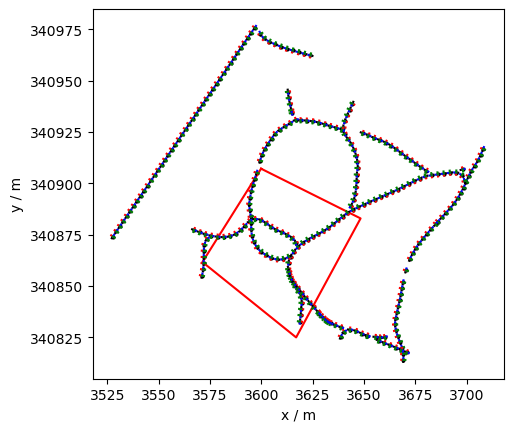

In [7]:
plt.plot(reduction_polygon[:, 0], reduction_polygon[:, 1], "r-")
dir_len = 1.
for i in range(0, len(image_meta_gdf[image_meta_gdf["sensor_id"] == 110021])):
	selection = image_meta_gdf[image_meta_gdf["sensor_id"] == 110021].iloc[i] # front-facing camera
	x, y = selection.geometry.x, selection.geometry.y
	plt.scatter(x, y, s=4, c="k")
	# Plot a small line from the camera position in the direction of the camera orientation (rz_rad)
	plt.plot(
		[x, x + dir_len * np.sin(selection.rz_rad)],
		[y, y + dir_len * np.cos(selection.rz_rad)],
		c="k",
	)
	selection = image_meta_gdf[image_meta_gdf["sensor_id"] == 110022].iloc[i] # right-racing camera (same position)
	plt.plot(
		[x, x + dir_len * np.sin(selection.rz_rad)],
		[y, y + dir_len * np.cos(selection.rz_rad)],
		c="r",
	)
	selection = image_meta_gdf[image_meta_gdf["sensor_id"] == 110023].iloc[i] # back-facing camera (same position)
	plt.plot(
		[x, x + dir_len * np.sin(selection.rz_rad)],
		[y, y + dir_len * np.cos(selection.rz_rad)],
		c="b",
	)
	selection = image_meta_gdf[image_meta_gdf["sensor_id"] == 110024].iloc[i] # left-facing camera (same position)
	plt.plot(
		[x, x + dir_len * np.sin(selection.rz_rad)],
		[y, y + dir_len * np.cos(selection.rz_rad)],
		c="g",
	)
	# Up and down work similarly, but we don't need to draw them right now

# Correct aspect ratio
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("x / m")
plt.ylabel("y / m")
plt.show()

In [8]:
# image_meta_gdf[image_meta_gdf["sensor_id"] == 110024].iloc[40:80][["sensor_id", "image_name", "x_m", "y_m", "rz_rad"]] # front-facing camera

In [5]:
import build_colmap_selection

In [6]:
image_meta_gdf = build_colmap_selection.load_image_meta("../../LiDAR_kappazunder_stadtpark/Los_6A/Bild-Meta/image_meta.txt", EPSG)
image_meta_gdf.head()

,trajectory_id,sensor_id,image_id,epoch_s,image_name,x_m,y_m,z_m,rx_rad,ry_rad,rz_rad,geometry
0,15767,110020,81077806,544305.54,WE1H2XH4.jpg,3708.061,340916.770,11.990,0.0,0.0,3.534082,POINT (3708.061 340916.77)
1,15767,110020,81077807,544306.76,WE1H2XH5.jpg,3706.875,340914.002,11.903,0.0,0.0,3.545221,POINT (3706.875 340914.002)
2,15767,110020,81077808,544308.01,WE1H2XH6.jpg,3705.571,340911.288,11.863,0.0,0.0,3.603837,POINT (3705.571 340911.288)
3,15767,110020,81077809,544309.27,WE1H2XH7.jpg,3704.008,340908.711,11.836,0.0,0.0,3.697283,POINT (3704.008 340908.711)
4,15767,110020,81077810,544310.42,WE1H2XH8.jpg,3702.398,340906.151,11.821,0.0,0.0,3.658704,POINT (3702.398 340906.151)


In [7]:
interior_df = build_colmap_selection.load_interior_orientation("../../LiDAR_kappazunder_stadtpark/Los_6B/Bild-Meta/interior_orientation.txt")
interior_df.head()

f:\Documents\LiDAR_kappazunder_stadpark_reduced\colmap_pipeline\build_colmap_selection.py:42: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv(path, sep="\t", index_col=False)


,sensor_id,type_projection,c_mm,psu_mm,psv_mm,pix_u,pix_v,dh_m,pitch_rad
0,110010,p,16.399,0.0046,0.0046,7130,7130,2.09,1.570796
1,110011,p,16.399,0.0046,0.0046,7130,7130,2.09,0.000000
2,110012,p,16.399,0.0046,0.0046,7130,7130,2.09,0.000000
3,110013,p,16.399,0.0046,0.0046,7130,7130,2.09,0.000000
4,110014,p,16.399,0.0046,0.0046,7130,7130,2.09,0.000000


In [8]:
fov_by_sensor = build_colmap_selection.load_fov_per_sensor("../../LiDAR_kappazunder_stadtpark/Los_6B/Bild-Meta/interior_orientation.txt")
fov_by_sensor

f:\Documents\LiDAR_kappazunder_stadpark_reduced\colmap_pipeline\build_colmap_selection.py:42: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv(path, sep="\t", index_col=False)


{110010: np.float64(1.5707963267948966),
 110011: np.float64(1.5707963267948966),
 110012: np.float64(1.5707963267948966),
 110013: np.float64(1.5707963267948966),
 110014: np.float64(1.5707963267948966),
 110015: np.float64(1.5707963267948966),
 110020: np.float64(1.5707963267948966),
 110021: np.float64(1.5707963267948966),
 110022: np.float64(1.5707963267948966),
 110023: np.float64(1.5707963267948966),
 110024: np.float64(1.5707963267948966),
 110025: np.float64(1.5707963267948966),
 110030: np.float64(1.5707963267948966),
 110031: np.float64(1.5707963267948966),
 110032: np.float64(1.5707963267948966),
 110033: np.float64(1.5707963267948966),
 110034: np.float64(1.5707963267948966),
 110035: np.float64(1.5707963267948966)}

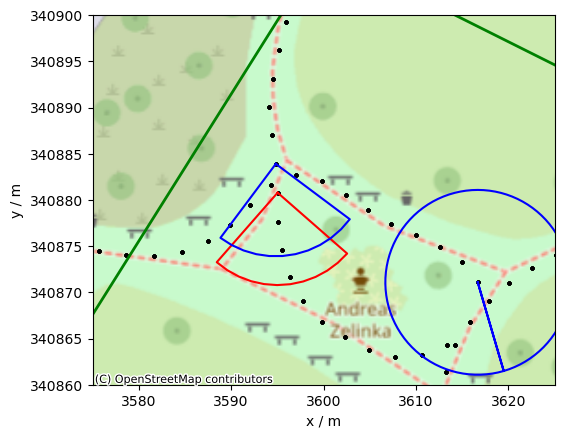

In [40]:
import contextily as ctx

fov = np.pi / 2

row = image_meta_gdf.iloc[394]
frustum = build_colmap_selection.make_frustum(row["x_m"], row["y_m"], row["rz_rad"], fov, 10)
fx, fy = frustum.exterior.xy
plt.plot(fx, fy, "r-")

row = image_meta_gdf.iloc[393]
frustum = build_colmap_selection.make_frustum(row["x_m"], row["y_m"], row["rz_rad"], fov, 10)
fx, fy = frustum.exterior.xy
plt.plot(fx, fy, "b-")

row = image_meta_gdf.iloc[405]
frustum = build_colmap_selection.make_frustum(row["x_m"], row["y_m"], row["rz_rad"], 2 * np.pi, 10, 100)
fx, fy = frustum.exterior.xy
plt.plot(fx, fy, "b-")

plt.scatter(image_meta_gdf["x_m"], image_meta_gdf["y_m"], s=4, c="k")
plt.xlim(3575, 3625)
plt.ylim(340860, 340900)
ctx.add_basemap(plt.gca(), crs=image_meta_gdf.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik, headers={'User-Agent': 'kappazunderUser/1.0 (https://github.com/yemsb/Kappazunder-Wien-3D-Gaussian-Splatting)'})

reduction_polygon = Polygon(np.array([
    [3599.8874170715394, 340907.17366641754],
    [3648.3580812379278, 340882.9493204322],
    [3616.96347532236,   340824.96835747146],
    [3571.3034212154816, 340861.6948829265],
    [3599.8874170715394, 340907.17366641754],
]))

# Plot reduction polygon
x, y = reduction_polygon.exterior.xy
plt.plot(x, y, "g-", linewidth=2)

plt.xlabel("x / m")
plt.ylabel("y / m")

# Equal aspect ratio
plt.gca().set_aspect("equal", adjustable="box")

In [9]:
pitch_by_sensor = interior_df.set_index("sensor_id")["pitch_rad"].to_dict()

image_meta_gdf = image_meta_gdf.copy()
image_meta_gdf["pitch_rad"] = image_meta_gdf["sensor_id"].map(pitch_by_sensor)

In [16]:
print(f"Loaded {len(image_meta_gdf)} image records.")
print(f"FOV by sensor (deg): "
	  f"{ {k: round(np.degrees(v),1) for k,v in fov_by_sensor.items()} }")

Loaded 1620 image records.
FOV by sensor (deg): {110010: np.float64(90.0), 110011: np.float64(90.0), 110012: np.float64(90.0), 110013: np.float64(90.0), 110014: np.float64(90.0), 110015: np.float64(90.0), 110020: np.float64(90.0), 110021: np.float64(90.0), 110022: np.float64(90.0), 110023: np.float64(90.0), 110024: np.float64(90.0), 110025: np.float64(90.0), 110030: np.float64(90.0), 110031: np.float64(90.0), 110032: np.float64(90.0), 110033: np.float64(90.0), 110034: np.float64(90.0), 110035: np.float64(90.0)}


In [10]:
from shapely.geometry import Polygon

In [11]:
from importlib import reload
reload(build_colmap_selection)

<module 'build_colmap_selection' from 'f:\\Documents\\LiDAR_kappazunder_stadpark_reduced\\colmap_pipeline\\build_colmap_selection.py'>

In [ ]:
reduction_polygon = Polygon(np.array([
    [3599.8874170715394, 340907.17366641754],
    [3648.3580812379278, 340882.9493204322],
    [3616.96347532236,   340824.96835747146],
    [3571.3034212154816, 340861.6948829265],
    [3599.8874170715394, 340907.17366641754],
]))
image_meta_gdf = build_colmap_selection.select_images(
	image_meta_gdf, reduction_polygon, fov_by_sensor, 10, raw_images_root="../../LiDAR_kappazunder_stadtpark/Los_6A/Bild-Rohdaten" # TODO: change back to MAX_FRUSTUM_DIST after testing
)

# TODO: remove this, it's just for debugging
# image_meta_gdf["selected"] = False
# image_meta_gdf.loc[0:227, "selected"] = True

n_selected = image_meta_gdf["selected"].sum()
print(f"Selected {n_selected} / {len(image_meta_gdf)} images "
	  f"(frustum intersects ROI).")

plot_path = "colmap_export/selection_preview.png"
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
build_colmap_selection.plot_selection(image_meta_gdf, reduction_polygon, fov_by_sensor,
				10, plot_path) # TODO: change back to MAX_FRUSTUM_DIST after testing

print(f"Saved selection preview: {plot_path}")

Found 228 mask images for selected images.
Selected 350 / 1620 images (frustum intersects ROI).
Saved selection preview: colmap_export/selection_preview.png


In [17]:
with np.printoptions(threshold=np.inf):
	print(image_meta_gdf["mask_path"].to_numpy())

[None None None None None None None None None None None None None None
 None None None None None None None None None None None None None None
 None None None None None None None None None None None None None None
 None None None None None None None None None None None None None None
 None None None None None None None None None None None None None None
 None None None None None None None None None None None None None None
 None None None None None None None None None None None None None None
 None None None None None None None None None None None None None None
 None None None None None None None None None None None None None None
 None None None None None None None None None None None None None None
 None None None None None None None None None None None None None None
 None None None None None None None None None None None None None None
 None None None None None None None None None None None None None None
 None None None None None None None None None None None None None None
 None 

In [15]:
selected_gdf

,trajectory_id,sensor_id,image_id,epoch_s,image_name,x_m,y_m,z_m,rx_rad,ry_rad,rz_rad,geometry,pitch_rad,selected,mask_path
50,15767,110020,81077992,544586.88,WE1H2XMA.jpg,3618.813,340832.720,11.940,0.000000,0.0,0.113762,POINT (3618.813 340832.72),1.570796,True,None
51,15767,110020,81077993,544588.03,WE1H2XMB.jpg,3619.129,340835.768,12.029,0.000000,0.0,0.096330,POINT (3619.129 340835.768),1.570796,True,None
52,15767,110020,81077994,544589.26,WE1H2XMC.jpg,3619.389,340838.776,12.138,0.000000,0.0,0.082238,POINT (3619.389 340838.776),1.570796,True,None
53,15767,110020,81077995,544590.50,WE1H2XMD.jpg,3619.612,340841.778,12.226,0.000000,0.0,0.035547,POINT (3619.612 340841.778),1.570796,True,None
54,15767,110020,81077996,544591.71,WE1H2XME.jpg,3619.308,340844.710,12.307,0.000000,0.0,6.022306,POINT (3619.308 340844.71),1.570796,True,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1110,15767,110024,81078141,544854.02,WE1H2XQF.jpg,3572.294,340870.184,12.439,-1.570796,0.0,1.859419,POINT (3572.294 340870.184),0.000000,True,None
1111,15767,110024,81078142,544855.07,WE1H2XQG.jpg,3571.998,340867.191,12.308,-1.570796,0.0,1.599102,POINT (3571.998 340867.191),0.000000,True,None
1112,15767,110024,81078143,544856.04,WE1H2XQH.jpg,3571.952,340864.159,12.213,-1.570796,0.0,1.574386,POINT (3571.952 340864.159),0.000000,True,None
1113,15767,110024,81078144,544856.97,WE1H2XQI.jpg,3571.869,340861.134,12.150,-1.570796,0.0,1.599231,POINT (3571.869 340861.134),0.000000,True,None


In [21]:
from rotation_conversion import sensor_role_from_pitch

In [22]:
sensor_ids = selected_gdf["sensor_id"]

front_facing_sensors = [i for i, _ in enumerate(sensor_ids) if sensor_role_from_pitch(sensor_ids.iloc[i]) == "front"]

In [29]:
selected_gdf.iloc[front_facing_sensors]

,trajectory_id,sensor_id,image_id,epoch_s,image_name,x_m,y_m,z_m,rx_rad,ry_rad,rz_rad,geometry,pitch_rad,selected,mask_path
278,15767,110021,81077992,544586.88,WE1H2XMA.jpg,3618.813,340832.720,11.940,-1.570796,0.0,0.113762,POINT (3618.813 340832.72),0.0,True,F:\Documents\LiDAR_kappazunder_stadtpark\Los_6...
279,15767,110021,81077993,544588.03,WE1H2XMB.jpg,3619.129,340835.768,12.029,-1.570796,0.0,0.096330,POINT (3619.129 340835.768),0.0,True,F:\Documents\LiDAR_kappazunder_stadtpark\Los_6...
280,15767,110021,81077994,544589.26,WE1H2XMC.jpg,3619.389,340838.776,12.138,-1.570796,0.0,0.082238,POINT (3619.389 340838.776),0.0,True,F:\Documents\LiDAR_kappazunder_stadtpark\Los_6...
281,15767,110021,81077995,544590.50,WE1H2XMD.jpg,3619.612,340841.778,12.226,-1.570796,0.0,0.035547,POINT (3619.612 340841.778),0.0,True,F:\Documents\LiDAR_kappazunder_stadtpark\Los_6...
282,15767,110021,81077996,544591.71,WE1H2XME.jpg,3619.308,340844.710,12.307,-1.570796,0.0,6.022306,POINT (3619.308 340844.71),0.0,True,F:\Documents\LiDAR_kappazunder_stadtpark\Los_6...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
415,15767,110021,81078130,544823.50,WE1H2XQ4.jpg,3592.038,340879.474,13.273,-1.570796,0.0,3.884205,POINT (3592.038 340879.474),0.0,True,F:\Documents\LiDAR_kappazunder_stadtpark\Los_6...
416,15767,110021,81078131,544824.79,WE1H2XQ5.jpg,3589.932,340877.308,13.281,-1.570796,0.0,3.920056,POINT (3589.932 340877.308),0.0,True,F:\Documents\LiDAR_kappazunder_stadtpark\Los_6...
417,15767,110021,81078132,544825.96,WE1H2XQ6.jpg,3587.471,340875.504,13.218,-1.570796,0.0,4.152531,POINT (3587.471 340875.504),0.0,True,F:\Documents\LiDAR_kappazunder_stadtpark\Los_6...
418,15767,110021,81078133,544826.94,WE1H2XQ7.jpg,3584.660,340874.369,13.108,-1.570796,0.0,4.404018,POINT (3584.66 340874.369),0.0,True,F:\Documents\LiDAR_kappazunder_stadtpark\Los_6...


In [18]:
selected_gdf = image_meta_gdf[image_meta_gdf["selected"]].copy()

if len(selected_gdf) == 0:
	print("No images selected -- check ROI polygon / MAX_FRUSTUM_DIST.")
else:
	# Center the scene on the selected images' centroid (in x,y; z kept
	# at the mean camera height so vertical values also stay small).
	scene_origin = (
		selected_gdf["x_m"].mean(),
		selected_gdf["y_m"].mean(),
		selected_gdf["z_m"].mean(),
	)
	print(f"Scene origin (EPSG:31256): "
			f"x={scene_origin[0]:.3f} y={scene_origin[1]:.3f} z={scene_origin[2]:.3f}")

	name_map = copy_and_rename_images(
		selected_gdf, RAW_IMAGES_ROOT, OUTPUT_IMAGES_DIR, copy=COPY_IMAGES, invert_masks=True
	)
	export_colmap(selected_gdf, interior_df, OUTPUT_SPARSE_DIR, name_map,
					scene_origin, INVERT_Y_AXIS)
	print(f"\nDone. COLMAP-format export at: {OUTPUT_DIR}")
	print(f"  {OUTPUT_DIR}/images/        <- (renamed) images"
			f"{'(not copied -- COPY_IMAGES=False)' if not COPY_IMAGES else ''}")
	print(f"  {OUTPUT_DIR}/sparse/0/      <- cameras.txt, images.txt, points3D.txt")
	print(f"  {OUTPUT_DIR}/scene_origin.txt  <- offset, reuse for LiDAR PLY export")

Scene origin (EPSG:31256): x=3613.603 y=340871.770 z=12.634
Wrote colmap_export\sparse\0\cameras.txt
Wrote colmap_export\sparse\0\images.txt
Wrote colmap_export\sparse\0\points3D.txt
Wrote colmap_export\scene_origin.txt  (offset: 3613.603, 340871.770, 12.634)

Done. COLMAP-format export at: colmap_export
  colmap_export/images/        <- (renamed) images
  colmap_export/sparse/0/      <- cameras.txt, images.txt, points3D.txt
  colmap_export/scene_origin.txt  <- offset, reuse for LiDAR PLY export


In [ ]:
interior_df.iloc[0]

sensor_id            110010
type_projection           p
c_mm                 16.399
psu_mm               0.0046
psv_mm               0.0046
pix_u                  7130
pix_v                  7130
dh_m                   2.09
pitch_rad          1.570796
Name: 0, dtype: object

In [ ]:
from laz_to_ply import *

In [ ]:
main()

Trajektorie_15767_AoI_thin.laz: 1,059,344 points
Total merged points: 1,059,344
Voxel downsampled (0.03 m): 1,059,344 -> 990,010 points
Wrote colmap_export\sparse\0\points3D_init.ply (990,010 points)


In [21]:
f = open("colmap_export/scene_origin.txt", "r")
lines = f.readlines()[3:6]
scene_origin = pd.DataFrame([line.strip().split() for line in lines], columns=["axis", "value"]).values[:, 1].astype(float)
scene_origin

array([3.60922875e+03, 3.40869381e+05, 1.27301390e+01])

In [19]:
import rotation_conversion

In [22]:
rotation_conversion.__main__()

AttributeError: module 'rotation_conversion' has no attribute '__main__'

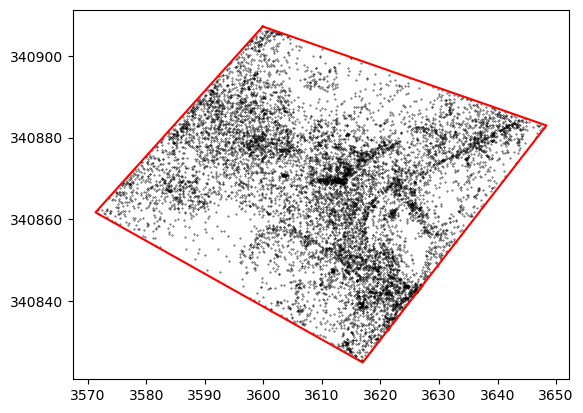

In [ ]:
LAZ_PATHS = [
    "data/Trajektorie_15767_AoI_thin.laz",
]

point_cloud_xy = read_laz_as_arrays(LAZ_PATHS[0])[0][:, :2][::100]

plt.scatter(point_cloud_xy[:, 0], point_cloud_xy[:, 1], s=0.1, c="k")
plt.plot(reduction_polygon[:, 0], reduction_polygon[:, 1], "r-")

In [ ]:
plt.plot(reduction_polygon[:, 0], reduction_polygon[:, 1], "r-")
dir_len = 1.
for i in range(0, len(image_meta_gdf[image_meta_gdf["sensor_id"] == 110021])):
	selection = image_meta_gdf[image_meta_gdf["sensor_id"] == 110021].iloc[i] # front-facing camera
	x, y = selection.geometry.x, selection.geometry.y
	plt.scatter(x, y, s=4, c="k")
	# Plot a small line from the camera position in the direction of the camera orientation (rz_rad)
	plt.plot(
		[x, x + dir_len * np.sin(selection.rz_rad)],
		[y, y + dir_len * np.cos(selection.rz_rad)],
		c="k",
	)
	selection = image_meta_gdf[image_meta_gdf["sensor_id"] == 110022].iloc[i] # right-racing camera (same position)
	plt.plot(
		[x, x + dir_len * np.sin(selection.rz_rad)],
		[y, y + dir_len * np.cos(selection.rz_rad)],
		c="r",
	)
	selection = image_meta_gdf[image_meta_gdf["sensor_id"] == 110023].iloc[i] # back-facing camera (same position)
	plt.plot(
		[x, x + dir_len * np.sin(selection.rz_rad)],
		[y, y + dir_len * np.cos(selection.rz_rad)],
		c="b",
	)
	selection = image_meta_gdf[image_meta_gdf["sensor_id"] == 110024].iloc[i] # left-facing camera (same position)
	plt.plot(
		[x, x + dir_len * np.sin(selection.rz_rad)],
		[y, y + dir_len * np.cos(selection.rz_rad)],
		c="g",
	)
	# Up and down work similarly, but we don't need to draw them right now

# Correct aspect ratio
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("x / m")
plt.ylabel("y / m")
plt.show()